<a href="https://colab.research.google.com/github/srivishnukaushal-lab/Data-Science-Portfolio/blob/main/Main_Project_Pattern_Discovery_With_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Essentials**

In [ ]:
# Importing necessary libraries:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy.stats import zscore
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

In [ ]:
# Mounting dataset from drive onto colab and defining dataset as copy of original:

from google.colab import drive
drive.mount ("/content/drive")

df = pd.read_excel ("/content/drive/My Drive/Colab Notebooks/Credit Card Customer Data.xlsx")

dataset = df.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Preprocessing**

In [ ]:
# Let's get an overview of our dataset.

dataset.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
dataset.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


- The columns of Sl_No and Customer Key are identifiers and not attributes of customers that are a part of the dataset. Therefore, we can remove these as part of preparing our dataset for analysis later on.

- We can also see that the Avg_Credit_Limit column has entries of a scale that is significantly greater than others such as Total_Credit_Cards or Total_visits_bank. As clustering algorithms are sensitive to scale, we will address this by scaling the dataset later.

In [ ]:
# Removing Sl_No and Customer Key columns:

dataset_an_org = dataset.drop ("Sl_No", axis=1)
dataset_an_org = dataset_an_org.drop ("Customer Key", axis=1)

dataset_an_org.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [ ]:
dataset.shape

(660, 7)

- Our dataset has 7 columns and 660 rows

In [ ]:
# We will check for null values in the dataset:

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


- The datatypes of all columns are integers, which makes sense based on the kind of information we expect to see in these columns.

- The number of non-null objects across all columns is 660, which is the same as the number of rows present in them. This suggests there are no null objects in the dataset. Before we can confirm this however, we will follow this with an additional check.

In [ ]:
columns = ["Avg_Credit_Limit", "Total_Credit_Cards", "Total_visits_bank", "Total_visits_online", "Total_calls_made"]

for i in columns:
  print (i, (dataset[i]==0).sum())

Avg_Credit_Limit 0
Total_Credit_Cards 0
Total_visits_bank 100
Total_visits_online 144
Total_calls_made 97


- We can see that some columns have numerous entries that are 0s. However, within the columns that do contain 0s, they seem to make sense as it is very possible there are customers who have made no vists online, in person or have not called the bank. Therefore, we will confirm that there are no null values in the dataset.

In [ ]:
# Next, let's check for duplicated observations in the dataset:

dataset.duplicated().sum()

np.int64(0)

- We can see there are no duplicated observations in the dataset, good.

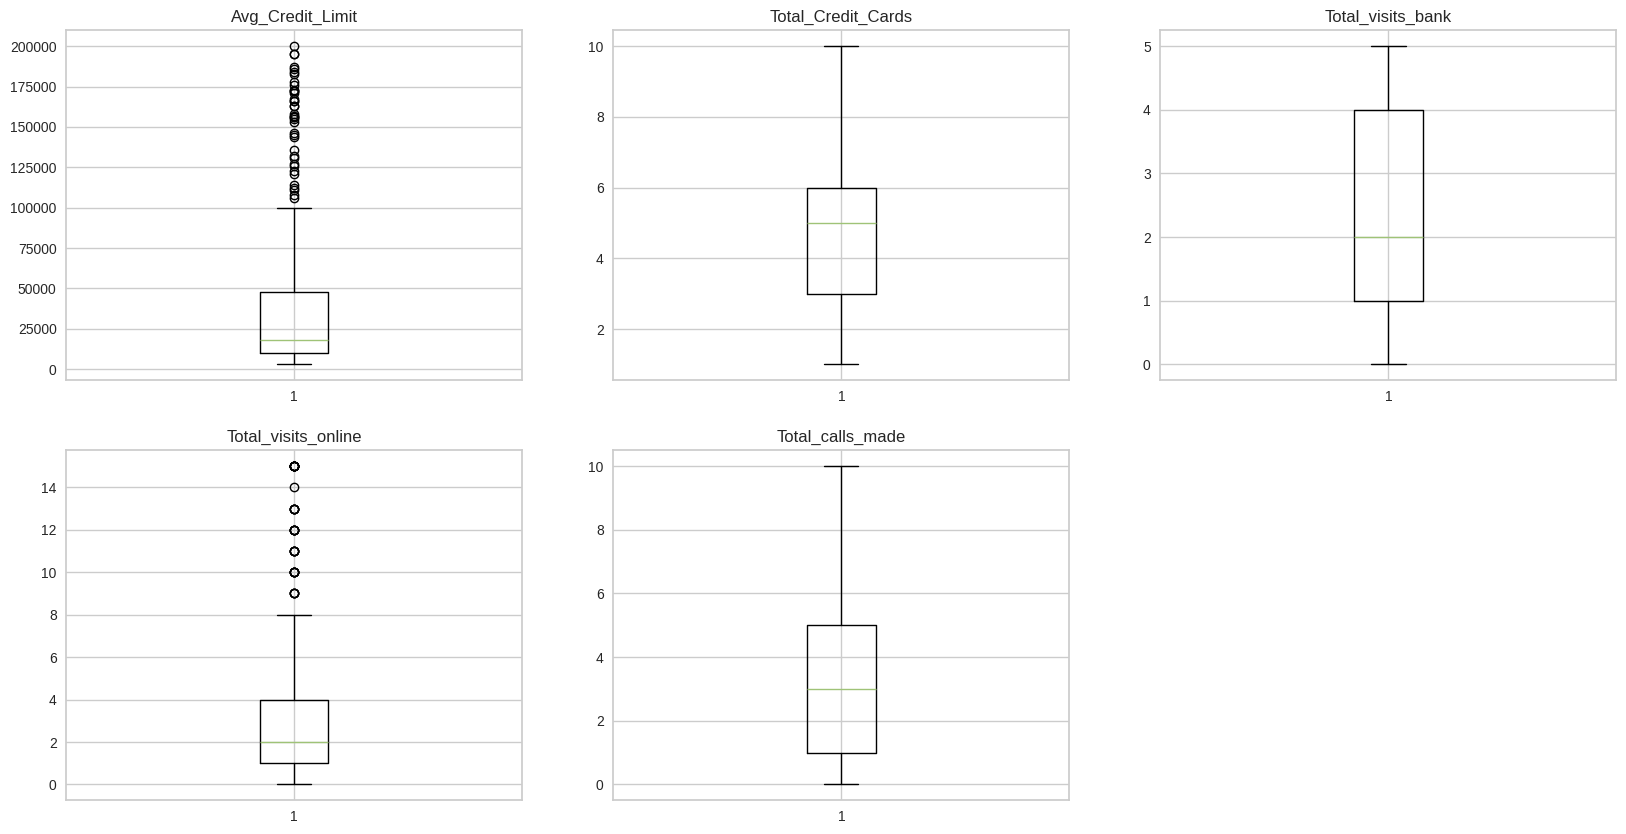

In [ ]:
# Now, let's check for problematic outliers:

plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

- We have some outliers on the higher end within the Avg_Credit_Limit and Total_visits_online columns.

- It is understandable that some customers have a higher credit limit than most because of their financial capacity. Hence, the outliers on the Avg_Credit_Limit don't seem problematic.

- While not typical perhaps, it is also possible that some customers make extensive online visits either for confidence or deeper knowledge. Hence, the outliers on the Total_visits_online column also seem valid.

- As this dataset is being prepared for analysis by unsupervised learning models, we don't have the need to split it into training and testing datasets.

- As all the columns contain entries that belong to the integer datatype to begin with, we are not required to do any feature engineering either.

In [ ]:
# We will proceed to scaling the dataset now:

dataset_an = dataset_an_org.apply (zscore)
dataset_an.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


- Great, our dataset is now ready for analysis by unsupervised models.

## **Exploratory Data Analysis**

**Problem Definition**

We are trying to find patterns within customers of the bank who are credit card holders to understand how the bank might market to them better and provide better support to them. We will conduct our exploratory data analysis in the context of this large picture.

### **Univariate Analysis**

In [ ]:
# Let's quickly get an overview of the metrics of each variable in the dataset:

dataset_an_org.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


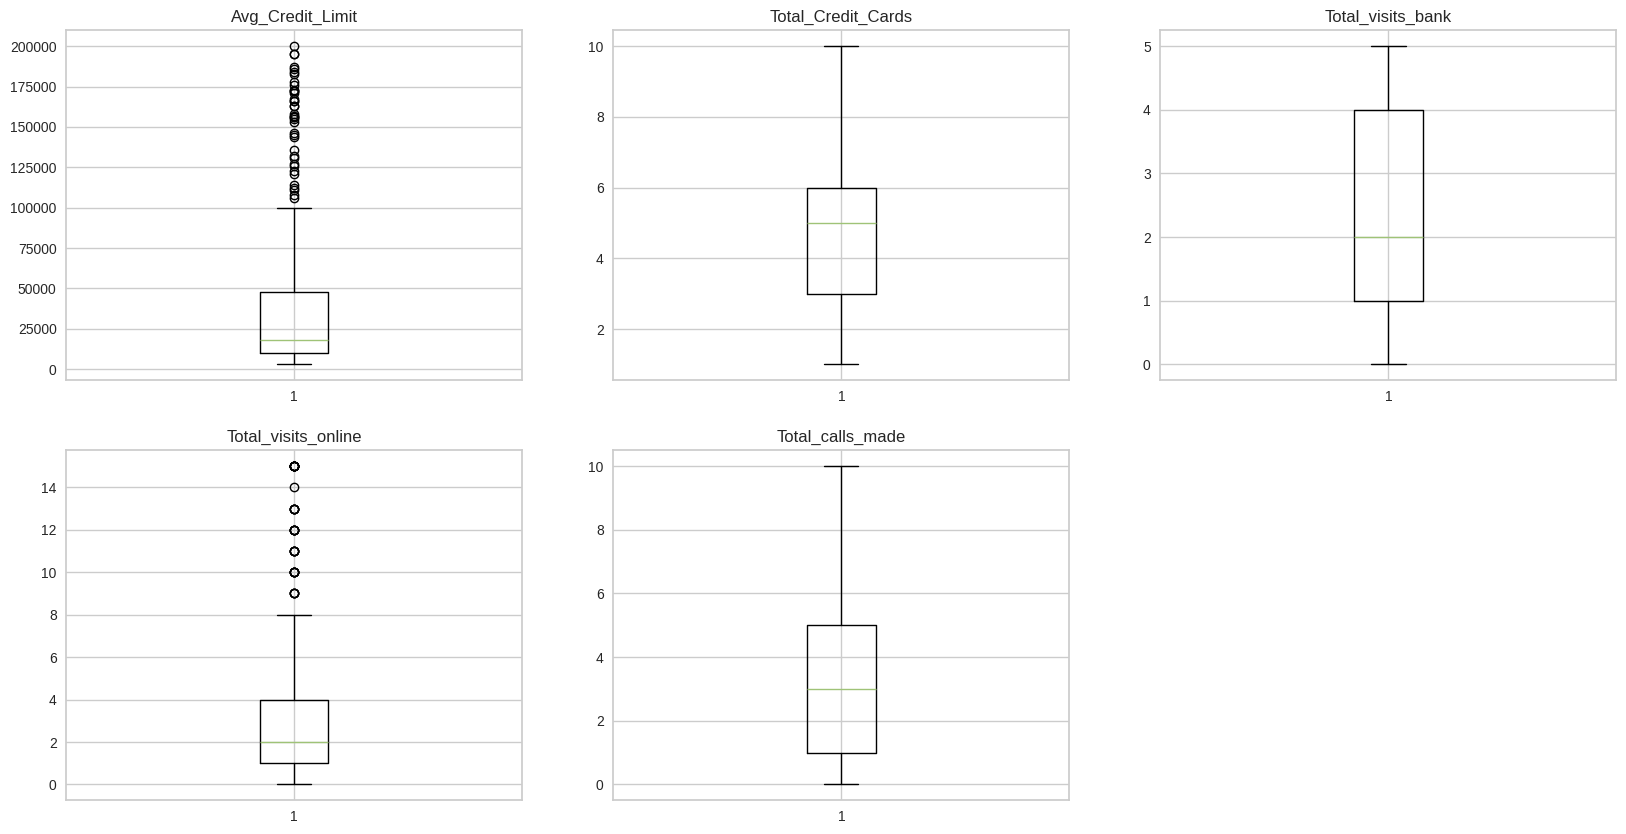

In [ ]:
# Let's also relook the box plots of our variables to understand their distribution:

plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

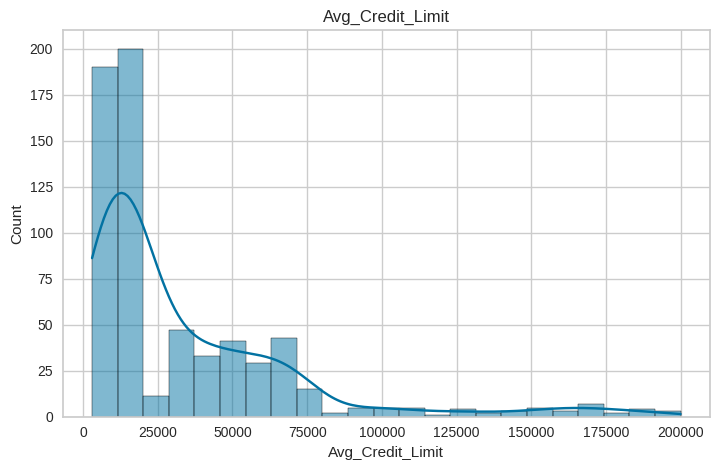

In [ ]:
# We will now move on by looking at histograms or countplots of all the variables:

sns.histplot (dataset["Avg_Credit_Limit"], kde=True)
plt.title("Avg_Credit_Limit")
plt.tight_layout (pad = 3)

plt.show()

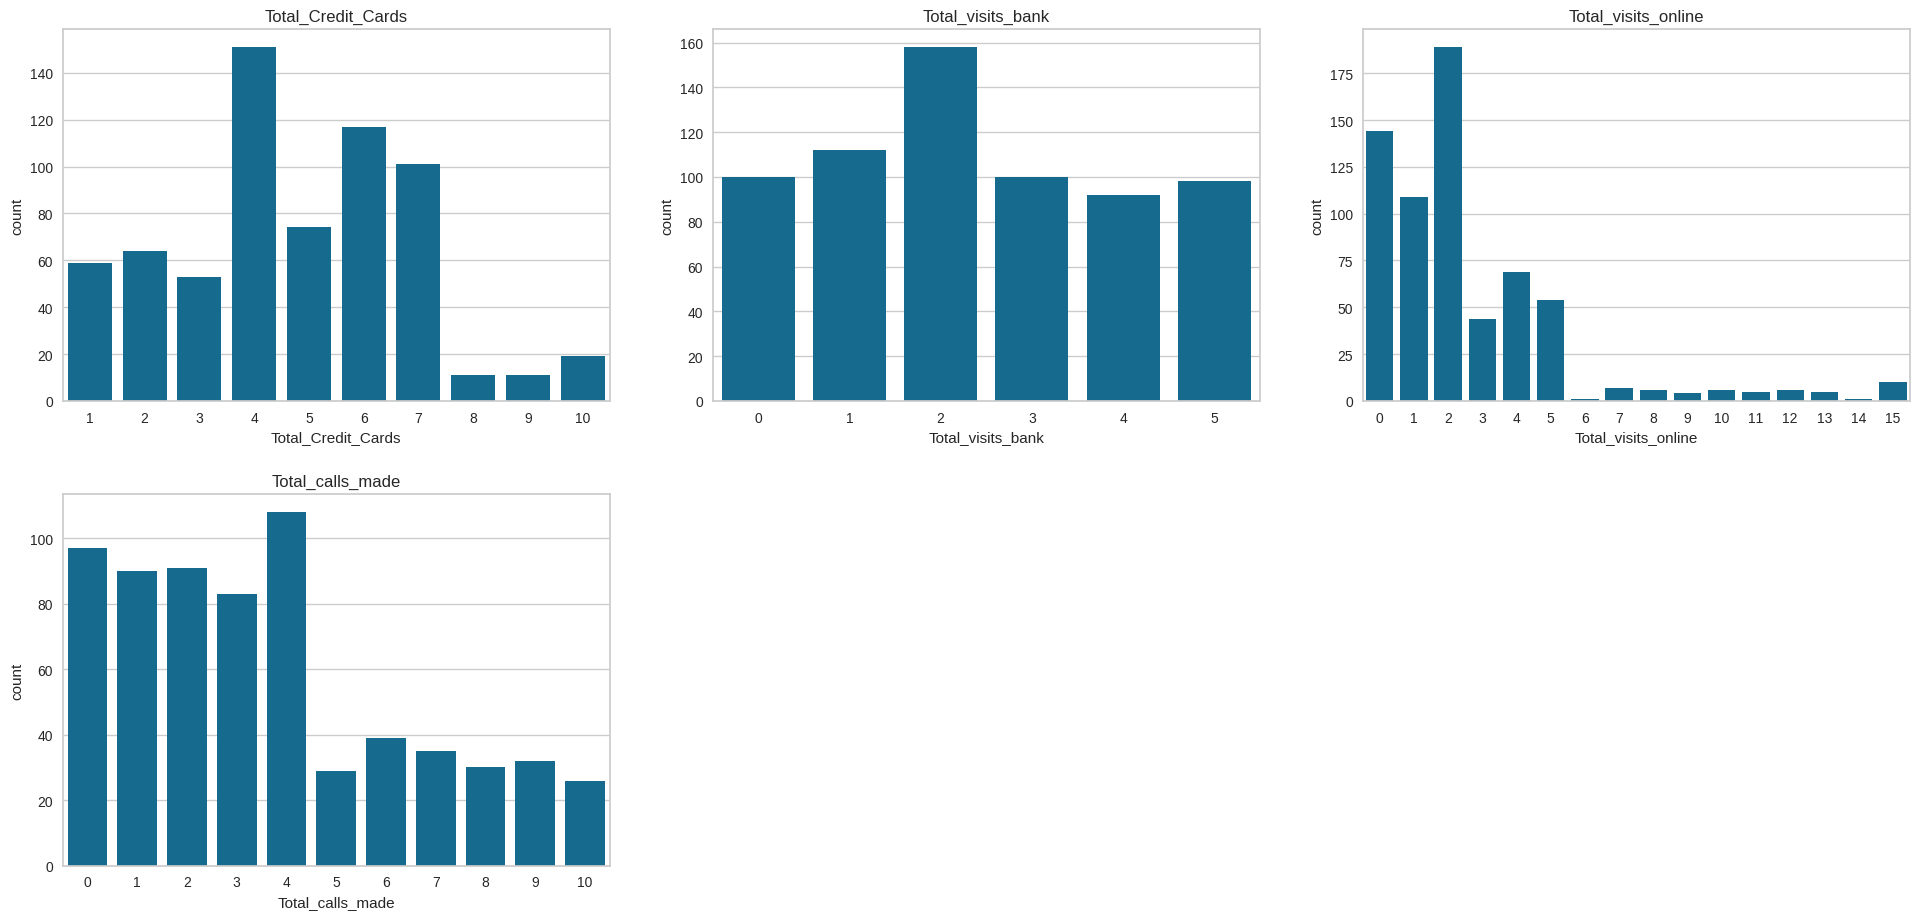

In [ ]:
columns = ["Total_Credit_Cards", "Total_visits_bank", "Total_visits_online", "Total_calls_made"]

plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable])
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

- We can see that the vast majority of customers have an average credit limit at the lower end of the spectrum. As we go towards the upper end, the number of customers is significantly less.

- People having between 4-7 credit cards are the highest in number. However, the number of people having fewer than 4 cards is not a significant drop. On the other hand, the number of people having more than 7 cards is considerably small.

- Total number of visits to the bank is relatively even across the range, with 2 visits being the most common of all others.

- Customers typically make upto 5 visits online, beyond which the traffic drops for higher number of online visits.

- When it comes to the total number of calls made, we see a similar pattern where customers typically make upto 4 calls, beyond which there's a significant drop in number of customers making a greater number of calls. The most common number of calls made is 4.

### **Bivariate Analysis**

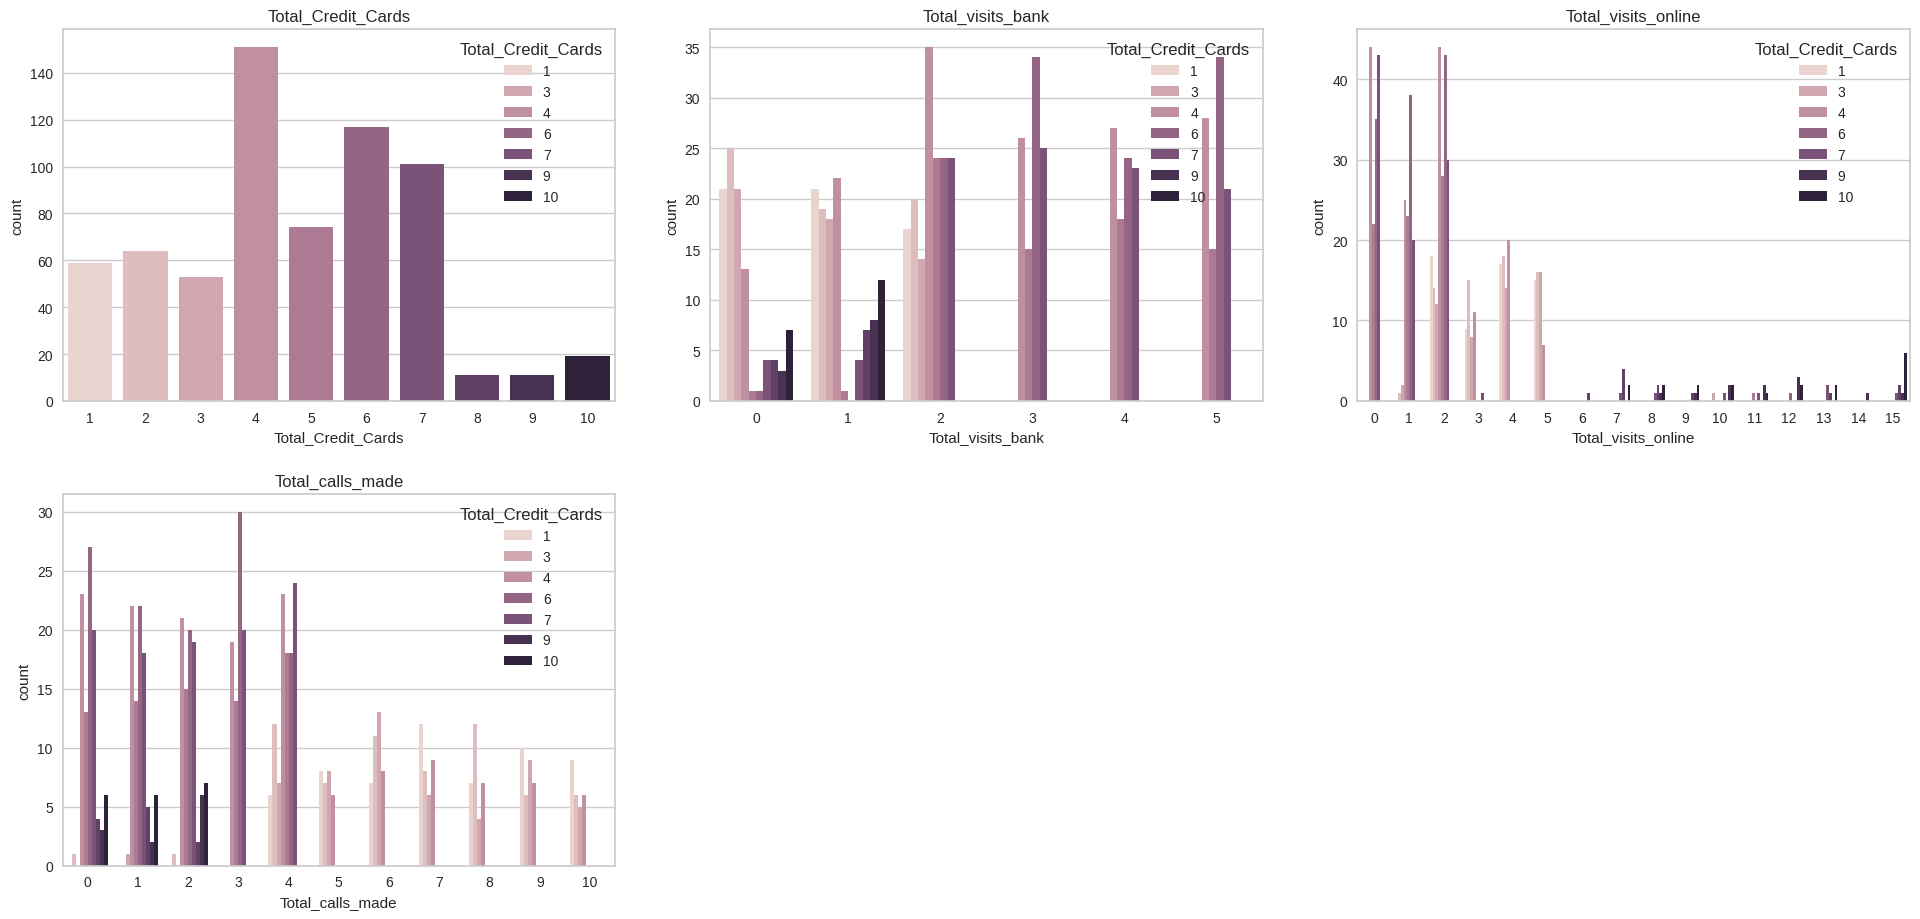

In [ ]:
# Now let's conduct bivariate analysis by comparing each variable against the others. Let's start with the discrete variables:

plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "Total_Credit_Cards")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

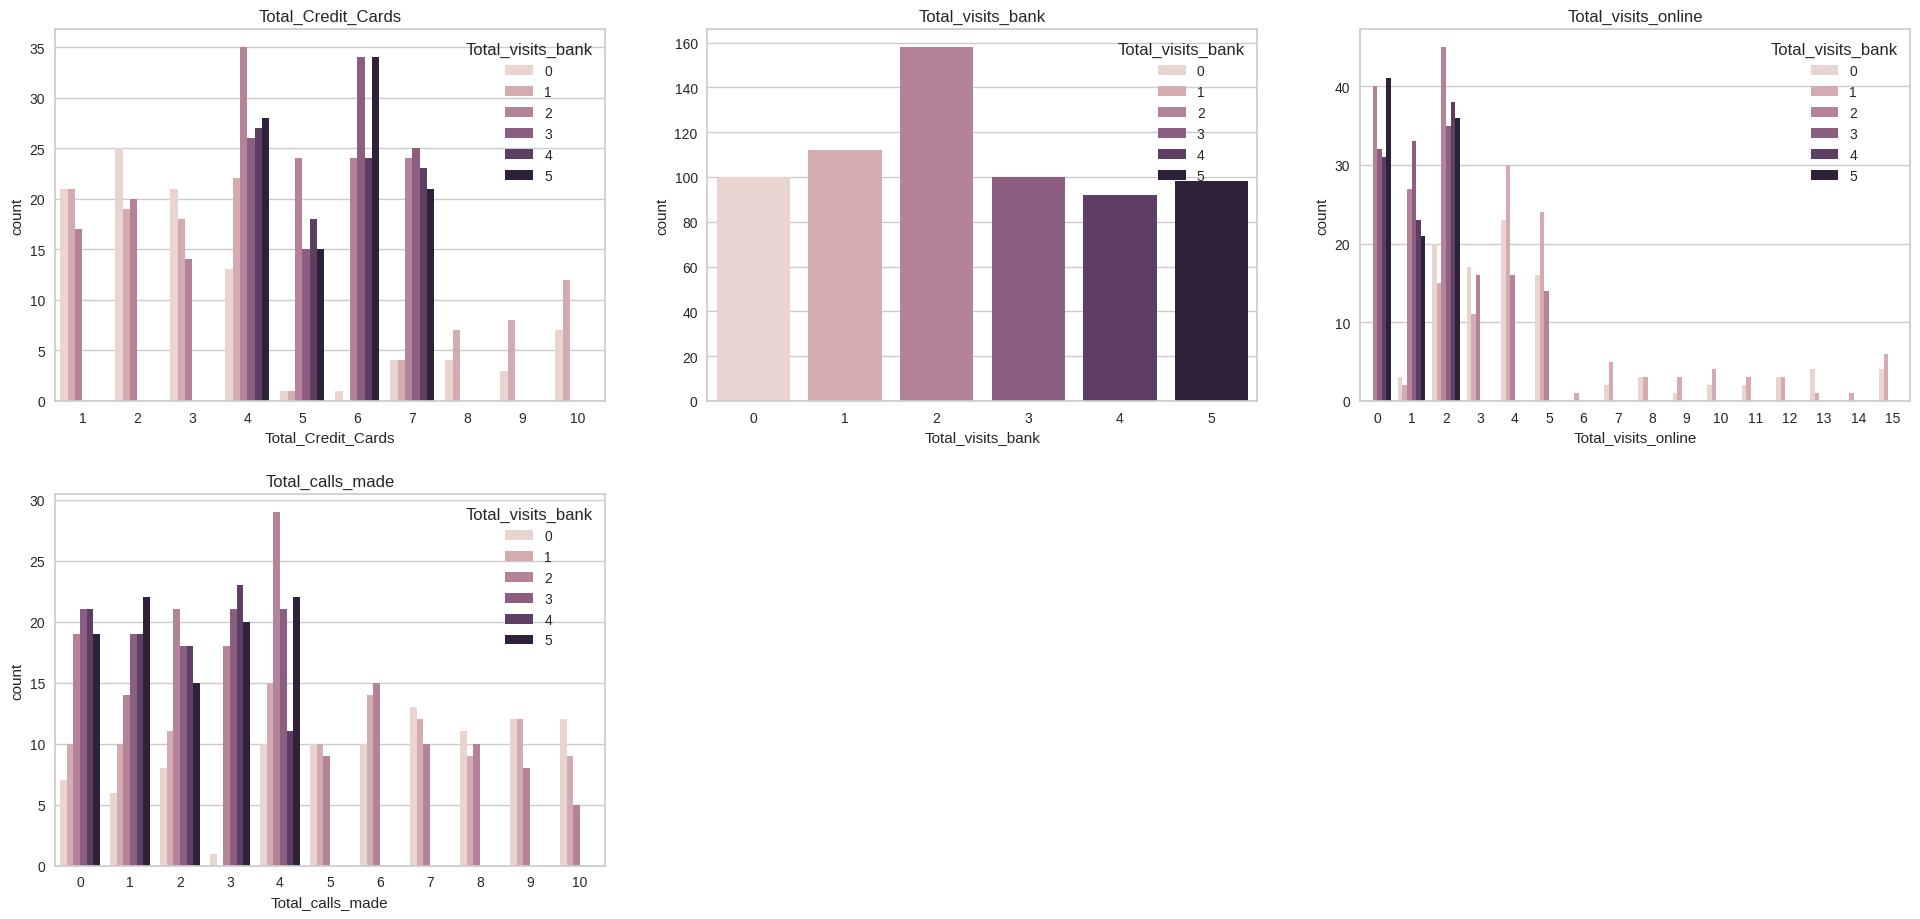

In [ ]:
plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "Total_visits_bank")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

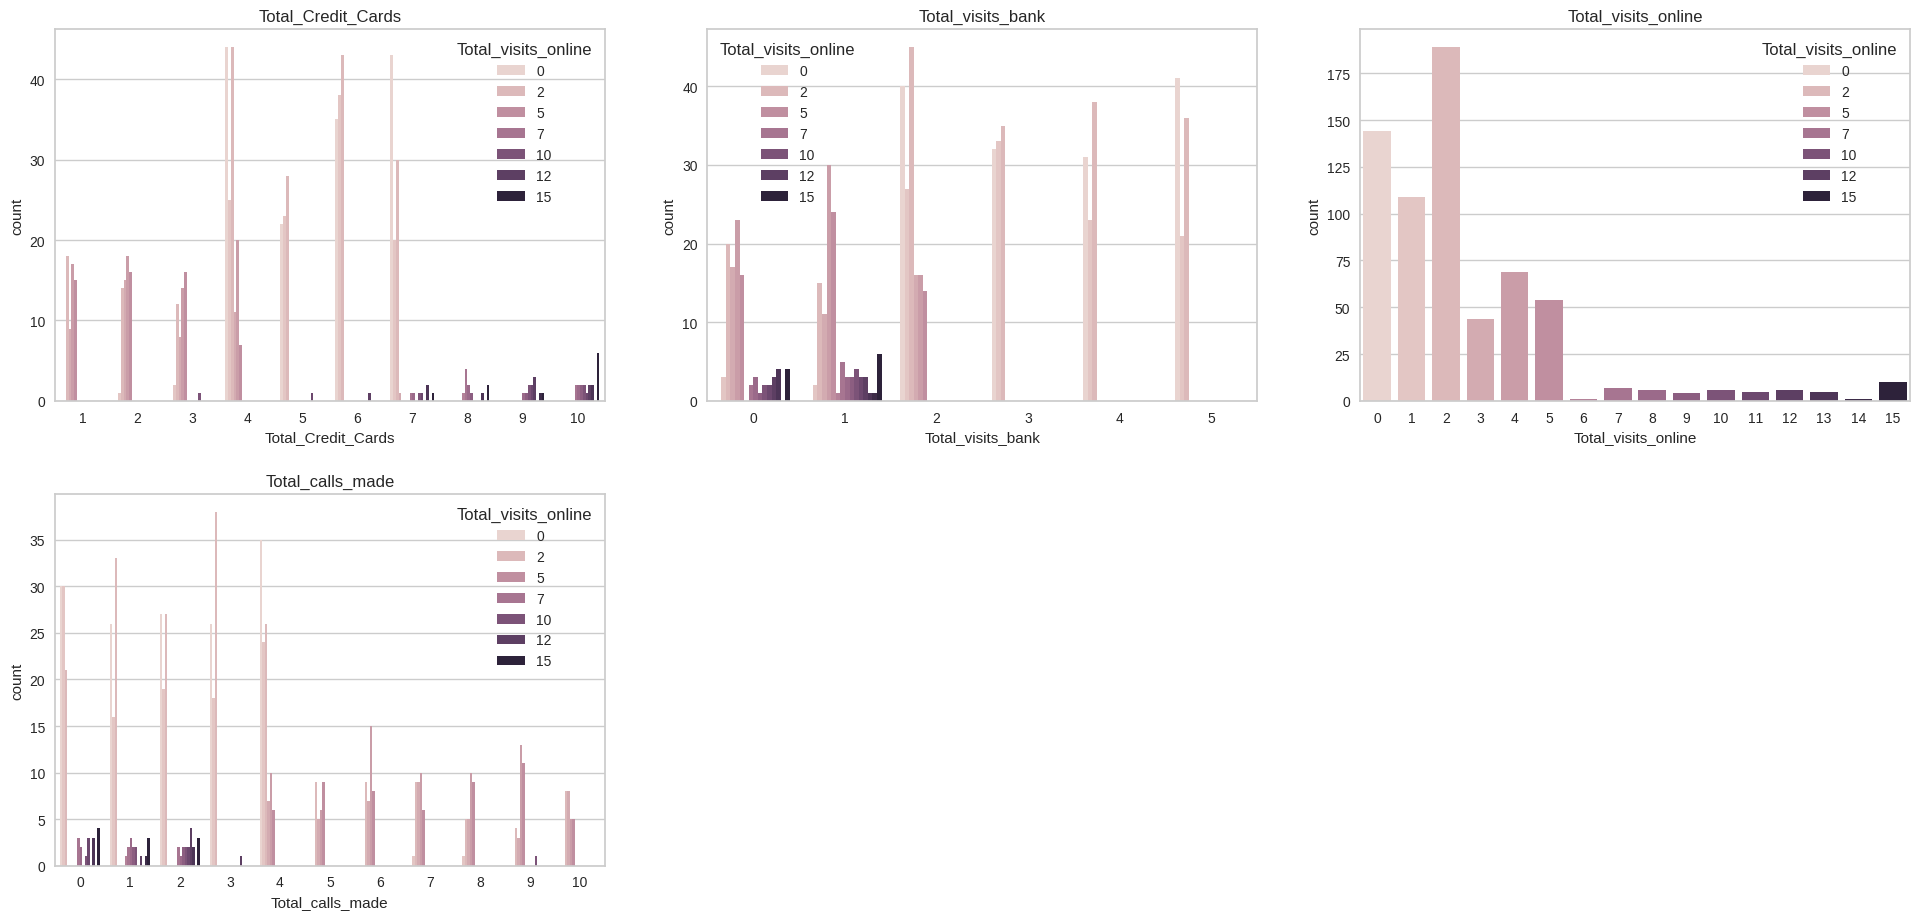

In [ ]:
plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "Total_visits_online")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

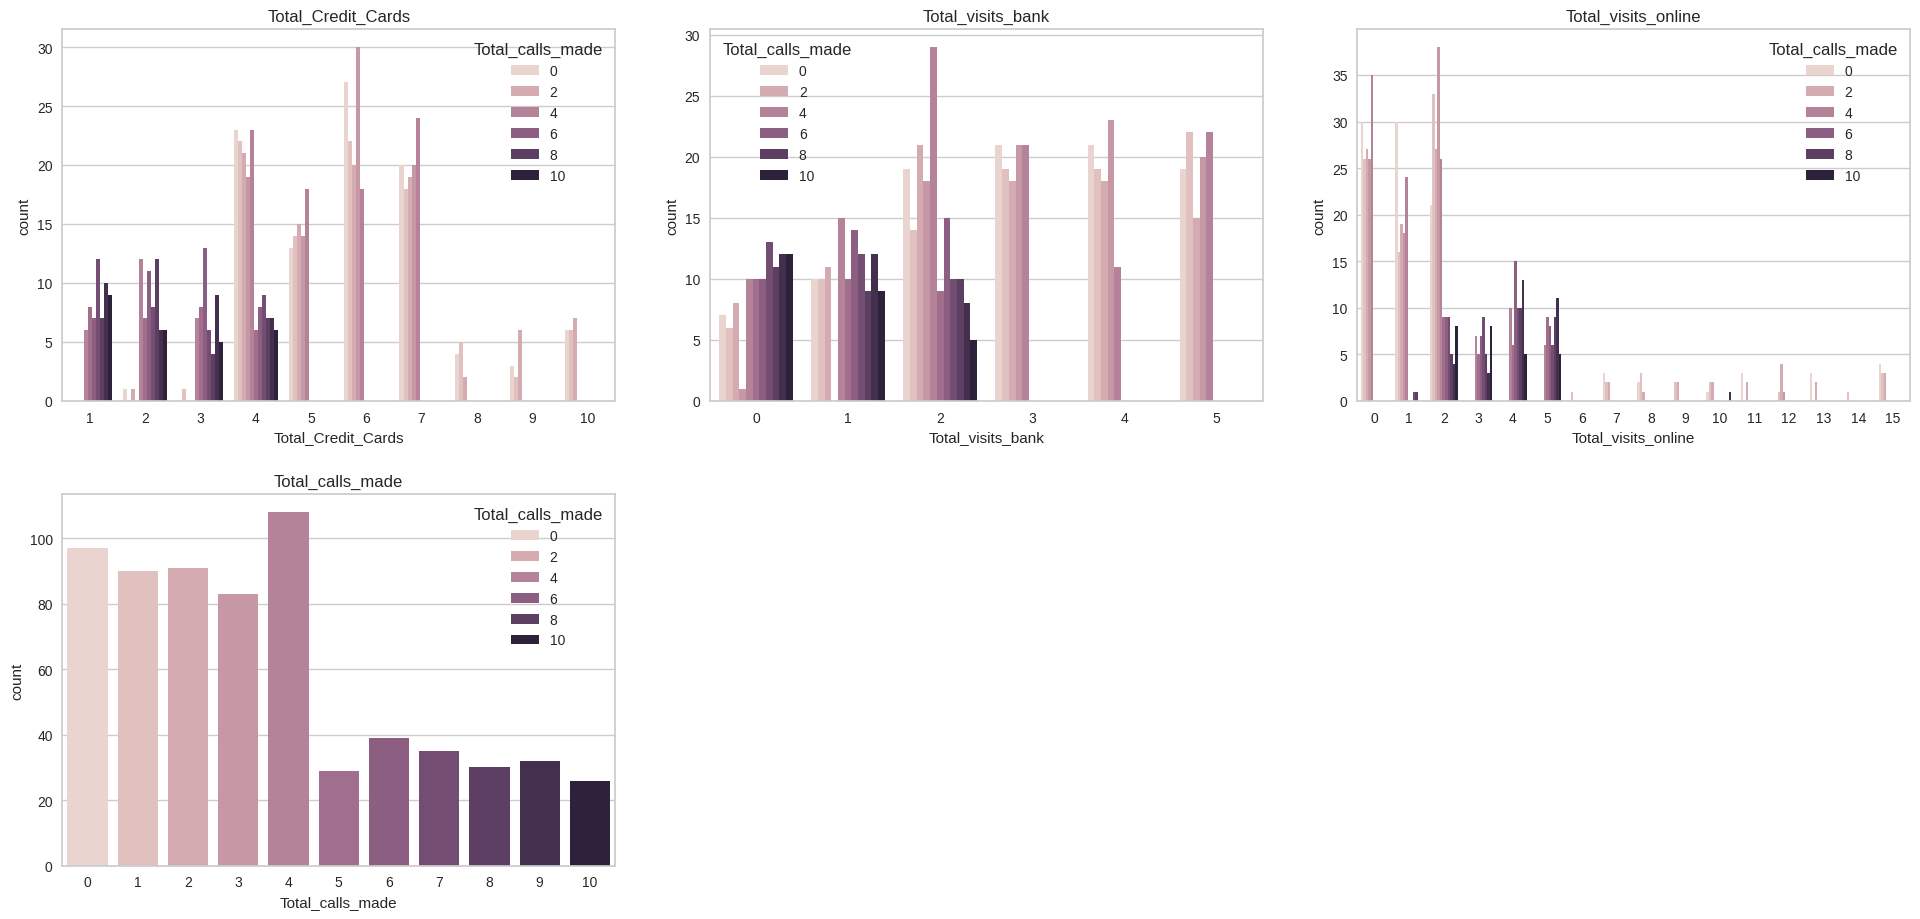

In [ ]:
plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "Total_calls_made")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

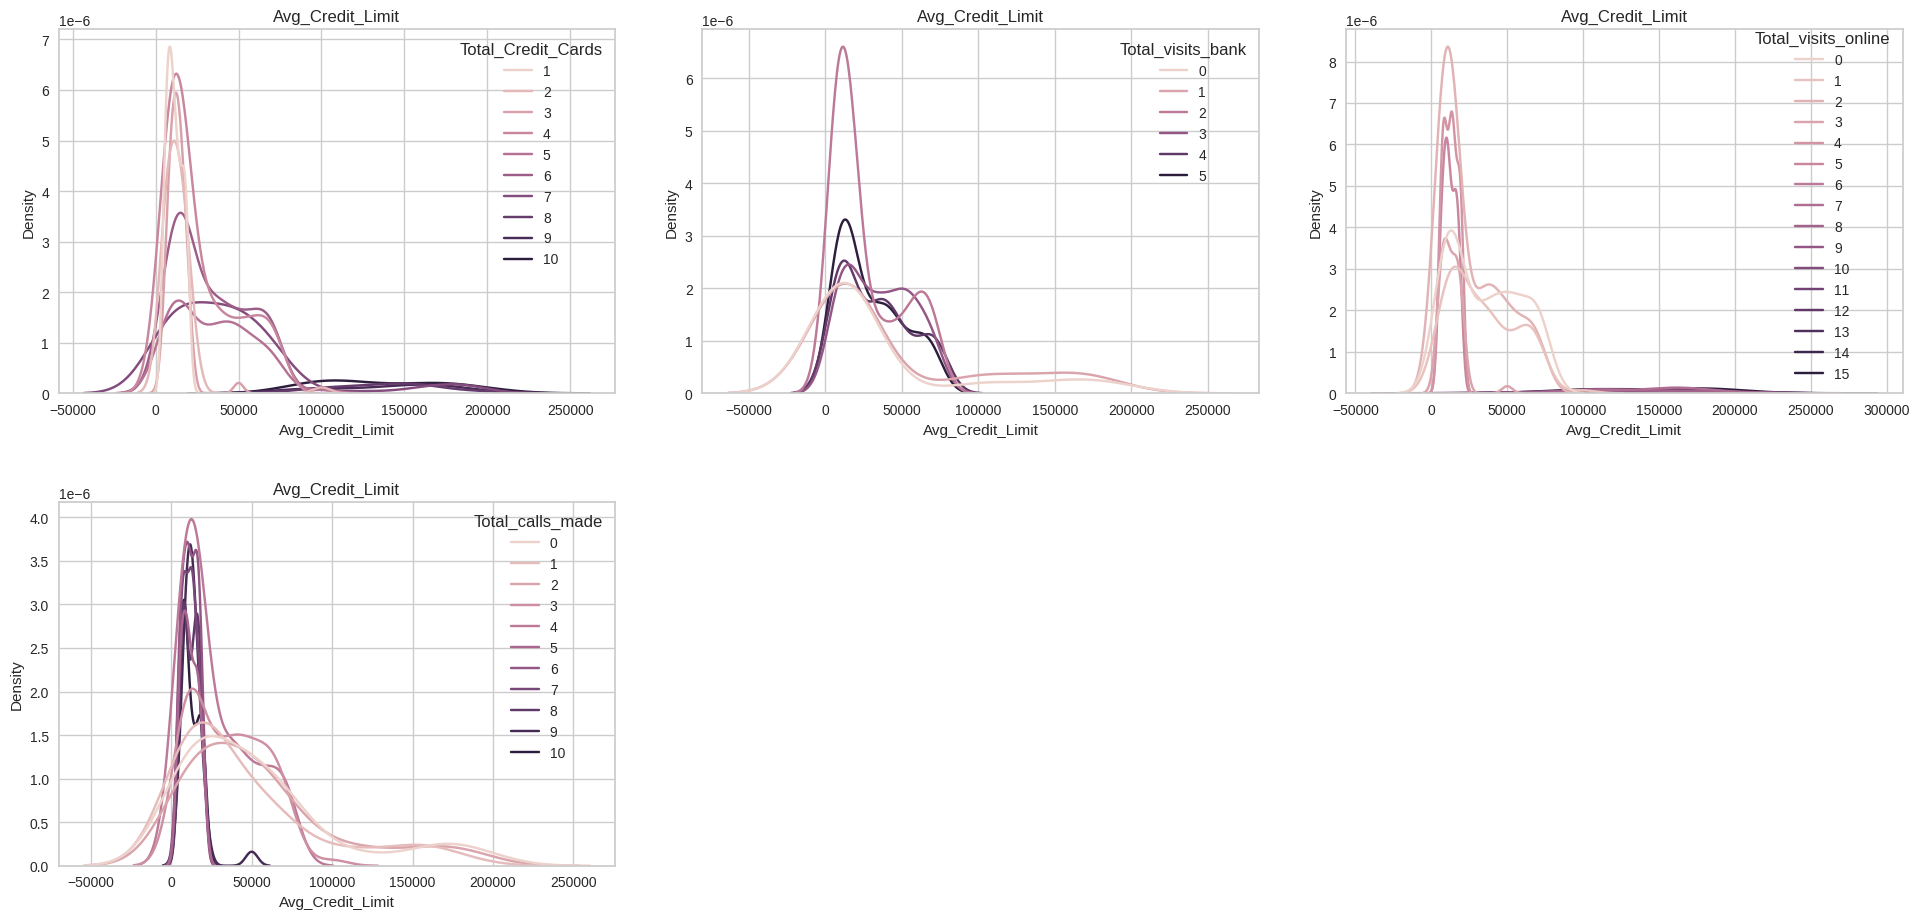

In [ ]:
# Now, let's look at the Avg_Credit_Limit (which we can treat as a continuous variable) variable against the other discrete variables:

plt.figure(figsize=(20,10))

for i, variable in enumerate(columns):
  plt.subplot(2, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset["Avg_Credit_Limit"], hue = variable, fill = False, warn_singular= False)
  plt.tight_layout (pad = 3)
  plt.title("Avg_Credit_Limit")

plt.show()

<Figure size 2000x1000 with 0 Axes>

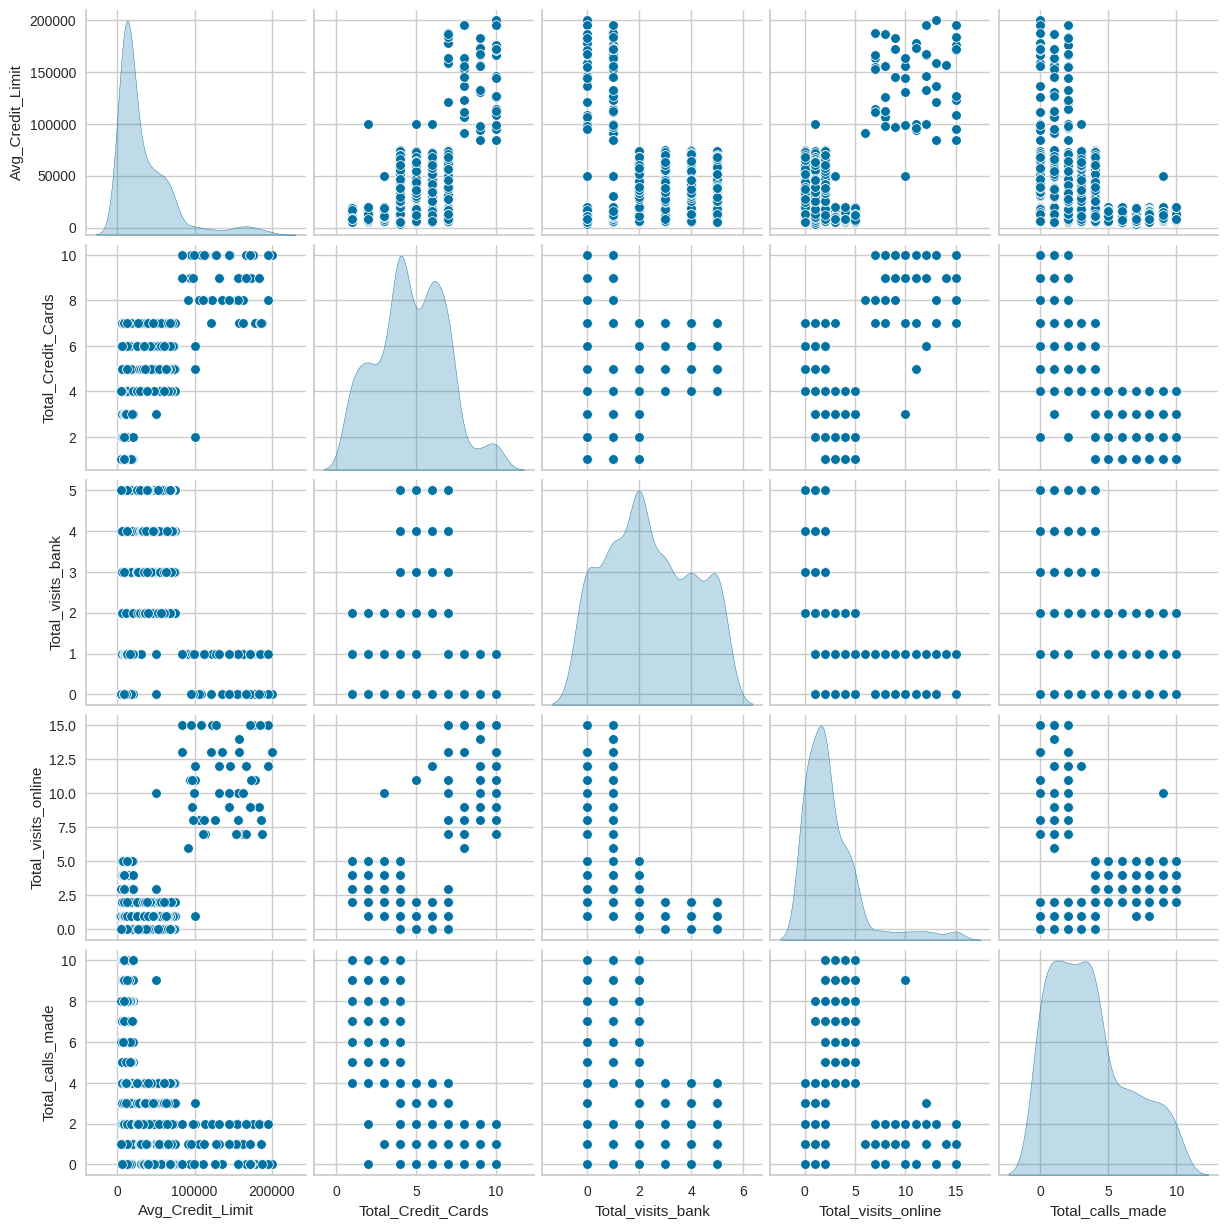

In [ ]:
# Now, let's look at a pairplot of the variables:

columns = ["Avg_Credit_Limit", "Total_Credit_Cards", "Total_visits_bank", "Total_visits_online", "Total_calls_made"]

plt.figure(figsize=(20,10))
sns.pairplot (dataset[columns], diag_kind="kde")

plt.show()

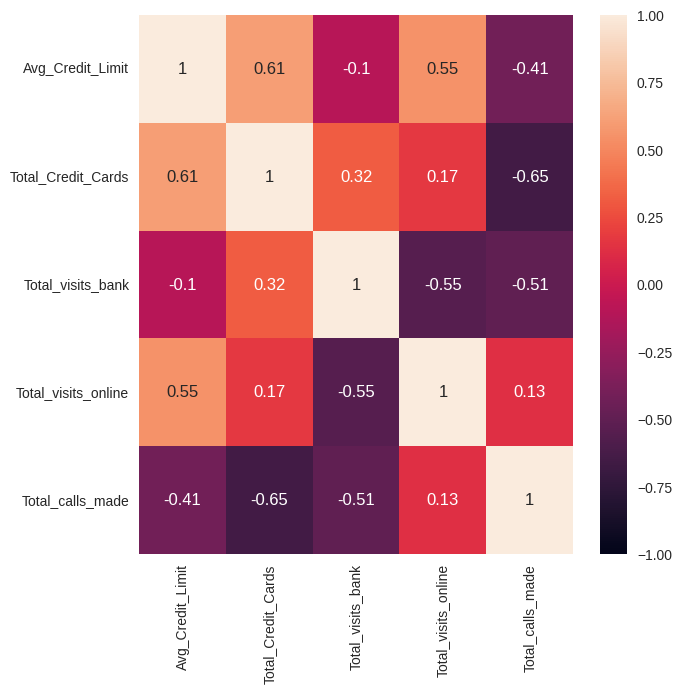

In [ ]:
# Lastly, let's look at a correlation matrix of the variables:

plt.figure(figsize=(7,7))
sns.heatmap(dataset_an_org.corr(), annot=True, vmin=-1, vmax=1)
plt.show()

- When we look at the variables broken down by the total number of credit cards held by the customer, we notice a few things. Customers with a higher number of credit cards (approximately 6 and above) behave differently across every variable as compared to those with a smaller number of credit cards (approximately below 6). Customers with a higher number of credit cards don't visit the bank more than once, are almost exclusively responsible for extensive numbers of online visits (above 6 vists), and don't make more than 2 calls to the bank.

- When we look at the variables broken down by the total number of visits made to the bank, we see a similar phenomenon where customers who make a larger number of visits to the bank (3 and above) behave differently across every variable as compared to those who make a smaller number of visits to the bank (beneath 3). Customers who make a larger number of visits to the bank almost entirely possess credits cards in the range of 4-7, don't make more than 2 visits online, and do not make more than 4 calls to the bank.

- We see a similar split between customers who make a higher number of visits online (approximately 6 and above) as compared to those who make fewer visits online (approximately below 6) when looking at the variables broken down by number of online visits. Customers who make a higher number of visits online possess higher number of credit cards as previously seen, don't make more than one visit to the bank, and don't make more than 2 calls to the bank.

- As previously seen with the other variables, we see a split in the behaviours of customers who make a higher number of calls to the bank (approximately 5 and above) and those who make fewer calls (beneath 5) when looking at the variables broken down by number of calls made to the bank. Along the lines of what we've already seen this far, customers who make a higher number of calls don't possess more than 4 credit cards, don;t make more than 2 visits to the bank, and don't make more than 5 visits online.

- When we look at the average credit limit per customer broken down by the rest of the variables, we notice a few things. Those with a high average credit limit also tend to have a higher number of credit cards, make more visits online, and make fewer visits and calls to the bank.

- The correlation matrix confirms our previous observations, as there are numbers pairs of variables for which the magnitude of correlation is greater than 0.5

- The contour of the pairplots and distributions of each variable suggests that there might be a minimum of 2 or 3 clusters in the dataset. We will see how this fairs up when we do our clustering analysis later.

## **K-Means Clustering**

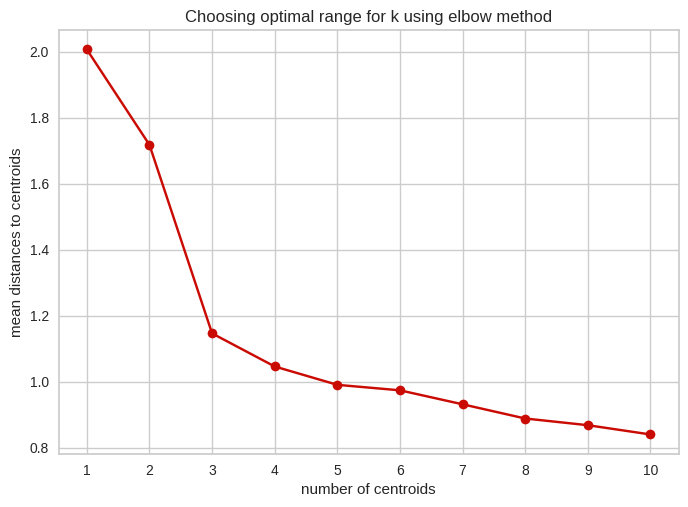

In [ ]:
# Let's start by building one model for each k value between 1 and 10.
# Then, we will plot the mean distance of points to their nearest centroid (conceptually another form of WCSS) against each model.
# Lastly, we will find the elbow on this graph to determine optimal range for k:

clusters= range (1,11)
mean_dist_to_centroid = []

for k in clusters:
  model_bld = KMeans (n_clusters=k)
  model_bld.fit (dataset_an)
  mean_dist_to_centroid.append (np.mean(np.min(cdist(dataset_an, model_bld.cluster_centers_, metric = "euclidean"), axis=1)))

plt.plot (clusters, mean_dist_to_centroid, "ro-")
plt.xticks (range(1,11))
plt.xlabel ("number of centroids")
plt.ylabel ("mean distances to centroids")
plt.title ("Choosing optimal range for k using elbow method")
plt.show()

- As we can see from the graph, the model with 3 clusters seems to strike the best balance between accuracy and compression (or usefulness). Additionally, the models up to about 5 or 6 clusters also seem to strike a good balance.

- We will therefore go ahead with a range between k=3 and k=6. This also largely aligns with what we saw previously from our pairplot in exploratory data analysis.

- We will pick the best value of k from within this range by comparing the silhoutte coefficients of models with different k values.

In [ ]:
# We will now find the silhouette scores for each value of k between 2 and 10, almost the same range that we used to find mean distances of points to their nearest centroids:

clusters= range (2,11)
sil_score = []

for k in clusters:
  model_bld = KMeans (n_clusters=k)
  model_pred = model_bld.fit_predict (dataset_an)
  score = silhouette_score (dataset_an, model_pred)
  sil_score.append (score)
  print ("for k =", k, "silhouette score is", round (score,2))

for k = 2 silhouette score is 0.42
for k = 3 silhouette score is 0.52
for k = 4 silhouette score is 0.34
for k = 5 silhouette score is 0.31
for k = 6 silhouette score is 0.26
for k = 7 silhouette score is 0.23
for k = 8 silhouette score is 0.23
for k = 9 silhouette score is 0.22
for k = 10 silhouette score is 0.21


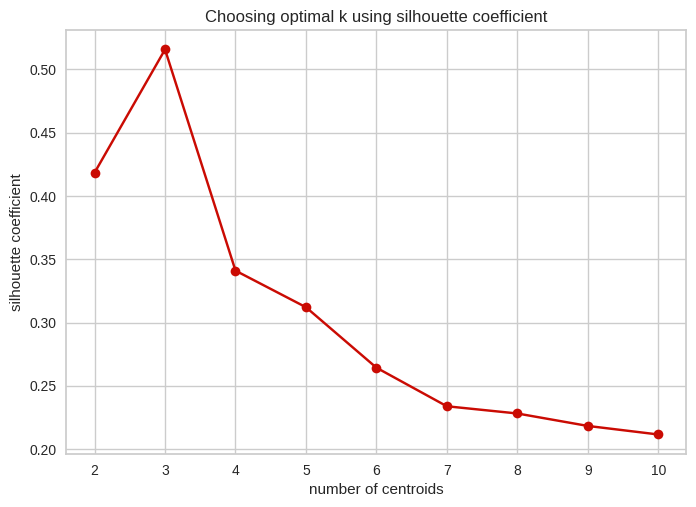

In [ ]:
# Let's also visualise these silhouette scores to help us pick the best value for k:

plt.plot (clusters, sil_score, "ro-")
plt.xlabel ("number of centroids")
plt.ylabel ("silhouette coefficient")
plt.title ("Choosing optimal k using silhouette coefficient")
plt.show()

- We can see that of all models with different k values, the model with k=3 is the one with the highest silhouette score. The silhouette score drops for models with a k value greater than 3.

- Even within the shortlisted range of k between 3 and 6 as determined by the elbow method from plotting mean distance of points to their nearest centroid against the models with different number of centroids, we see that the model with 3 clusters is the one with the highest silhouette score and not the models with 4 clusters or 5 clusters.

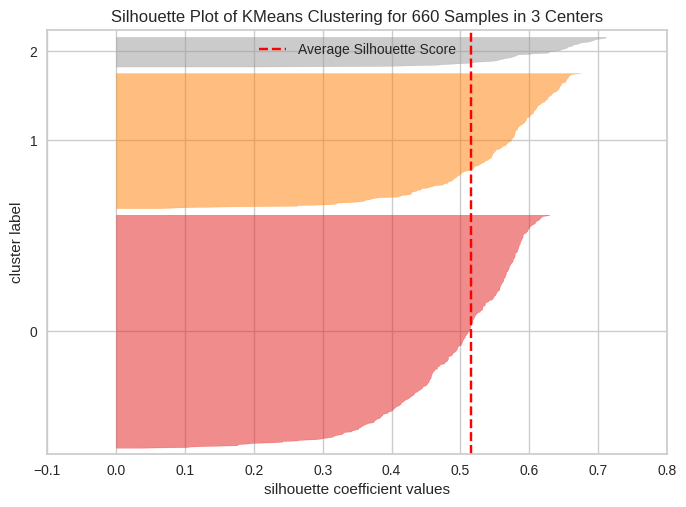

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# We will now visualise how the silhouette scores are distributed within the model of k=3:

model_k3 = KMeans (n_clusters=3)
visualizer = SilhouetteVisualizer (model_k3)

visualizer.fit (dataset_an)
visualizer.show()

- Across the board, we can see that there are no negetive silhouette scores. This is perfect as it suggests every single datapoint is categorised so that it is closer to its own cluster than to any other cluster.

- Clusters 0 and 2 have a broader range of silhouette scores within them, but this is understandable because they also have a greater number of datapoints present within them.

- The highest model silhouette score of 0.52, positive silhouette scores across the board, and comparable silhouette scores across different clusters all point to good seperation of clusters within this model where k=3.

- **We will therefore finalise this model, model_k3 as the one we go ahead with** as it finds the best balance between accuracy and compression while also having the best seperation amongst all other models with different k values.

In [ ]:
# We will now move on to profiling the clusters in our final model.
# We will start by establishing our final model and adding its predictions to the scaled and orginal datasets:

model_final_bld = KMeans (n_clusters=3)
model_final_pred = model_final_bld.fit_predict (dataset_an)

dataset_an_org_labels = dataset_an_org.copy()
dataset_an_org_labels ["Group_KMeans"] = model_final_pred

dataset_an_labels = dataset_an.copy()
dataset_an_labels ["Group_KMeans"] = model_final_pred

dataset_an_org_labels.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans
0,100000,2,1,1,0,0
1,50000,3,0,10,9,1
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,2


In [ ]:
dataset_an_labels.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537,0
1,0.410293,-0.787585,-1.473731,2.520519,1.891859,1
2,0.410293,1.058973,-0.860451,0.134290,0.145528,0
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528,0
4,1.740187,0.597334,-1.473731,3.202298,-0.203739,2


- Great, we can see the predictions have been added to the scaled and orginal datasets, and we can see 3 groups present within them: groups with index labels 0, 1 and 2.

In [ ]:
# We will now do the profiling. We will look at a summary on the orginal dataset so we can see actual values:

dataset_an_org_profile = dataset_an_org_labels.groupby (["Group_KMeans"])
dataset_an_org_profile.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Group_KMeans,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000
1,12174.107143,2.410714,0.933036,3.553571,6.870536
2,141040.000000,8.740000,0.600000,10.900000,1.080000


In [ ]:
dataset_an_org_profile.median()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_Hier
Group_KMeans,,,,,,
0,31000.0,6.0,3.0,1.0,2.0,0.0
1,12000.0,2.0,1.0,4.0,7.0,2.0
2,145500.0,9.0,1.0,11.0,1.0,1.0


array([[<Axes: title={'center': 'Avg_Credit_Limit'}, xlabel='[Group_KMeans]'>,
        <Axes: title={'center': 'Total_Credit_Cards'}, xlabel='[Group_KMeans]'>],
       [<Axes: title={'center': 'Total_calls_made'}, xlabel='[Group_KMeans]'>,
        <Axes: title={'center': 'Total_visits_bank'}, xlabel='[Group_KMeans]'>],
       [<Axes: title={'center': 'Total_visits_online'}, xlabel='[Group_KMeans]'>,
        <Axes: >]], dtype=object)

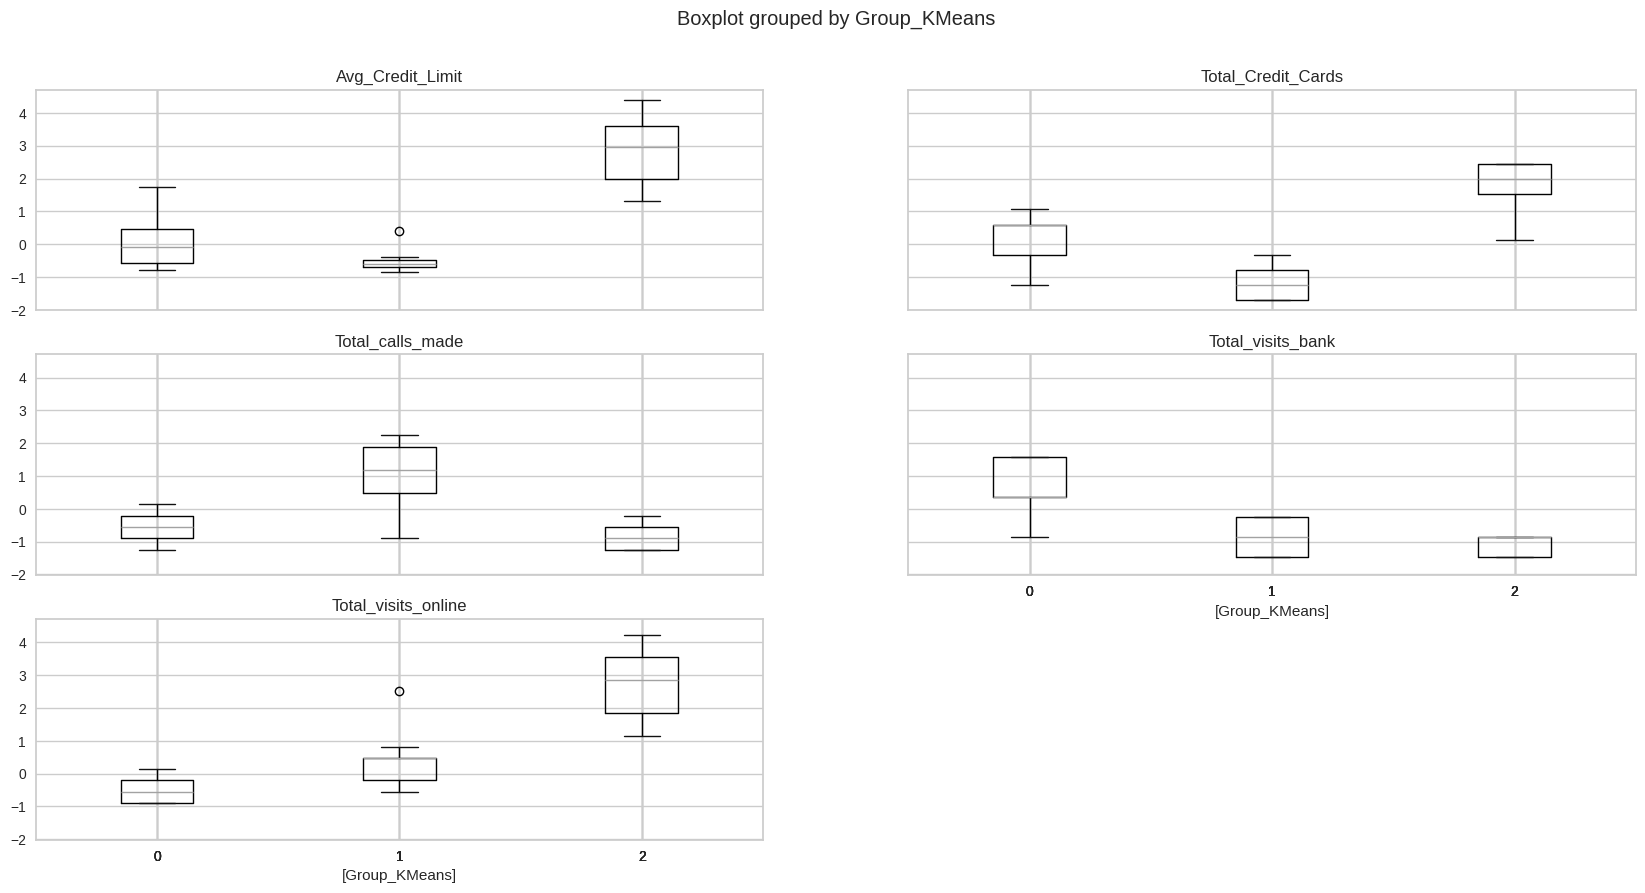

In [ ]:
# We will visualise the grouping using boxplots for each variable.
# We will use the scaled dataset this time to better see patterns and compare:

dataset_an_labels.boxplot (by="Group_KMeans", figsize = (20,10))

- Average credit limit: cluster 1 has average credit limits beneath the mean of the variable, with one outlier above it. Cluster 0 has a distribution centred around the mean, and cluster 2 has a distribution that is much higher, with its median around 3 standard deviations from the mean. There is significant seperation amongst the clusters on the average credit limit variable.

- Total credit cards: we see a similar pattern where cluster 1 has a distribution beneath the mean, cluster 0 has a distribution around the mean, and cluster 2 has a distribution much higher, with its median around 2 standard deviations from the mean. Again, there is significant seperation, and a similar one at that, amongst the clusters on the total credit cards variable too.

- Total calls made: cluster 1 is the one with the highest distribution this time, with its median around 1 standard deviation higher than the mean. Clusters 0 and 2 are similar to one another, and are beneath the mean. There is noticeable seperation on the total calls made variable too, although it is mostly seen with respect to cluster 1.

- Total visits to bank: cluster 0 is the one that has a higher distribution this time, while clusters 1 and 2 are similar to one another. Cluster 2 has a narrower distribution as compared to cluster 1. We see reasonable seperation here too.

- Total visits online: cluster 2 has the highest distribution, with cluster 0 having the least. We see seperation between the clusters here as well.

## **Hierarchical Clustering**

In [ ]:
# We will start by applying hierarchical clustering and building a dendrogram using each linkage method:

hier_model_1 = linkage (dataset_an, metric="euclidean", method="single")
hier_model_2 = linkage (dataset_an, metric="euclidean", method="complete")
hier_model_3 = linkage (dataset_an, metric="euclidean", method="average")
hier_model_4 = linkage (dataset_an, metric="euclidean", method="centroid")
hier_model_5 = linkage (dataset_an, metric="euclidean", method="ward")

In [ ]:
# Now, we will get the cophenetic correlation for each dendrogram:

coph_corr_1, coph_dists_1 = cophenet (hier_model_1, pdist(dataset_an))
coph_corr_2, coph_dists_2 = cophenet (hier_model_2, pdist(dataset_an))
coph_corr_3, coph_dists_3 = cophenet (hier_model_3, pdist(dataset_an))
coph_corr_4, coph_dists_4 = cophenet (hier_model_4, pdist(dataset_an))
coph_corr_5, coph_dists_5 = cophenet (hier_model_5, pdist(dataset_an))

print ("cophenetic correlation of model 1: ", round(coph_corr_1, 2), "\n",
       "cophenetic correlation of model 2: ", round(coph_corr_2, 2), "\n",
       "cophenetic correlation of model 3: ", round(coph_corr_3, 2), "\n",
       "cophenetic correlation of model 4: ", round(coph_corr_4, 2), "\n",
       "cophenetic correlation of model 5: ", round(coph_corr_5, 2))

cophenetic correlation of model 1:  0.74 
 cophenetic correlation of model 2:  0.86 
 cophenetic correlation of model 3:  0.9 
 cophenetic correlation of model 4:  0.89 
 cophenetic correlation of model 5:  0.74


- We can see from the cophenetic correlations of the different models that the ones built using the linkage methods of complete, average, and centroid have the highest scores, while the models built using the linkage methods of single and ward fall behind.

- That being said, the model built using the linkage method of average has the highest cophenetic correlation score of 0.90. **We can therefore infer from this that this dendogram is the best amongst all others.**

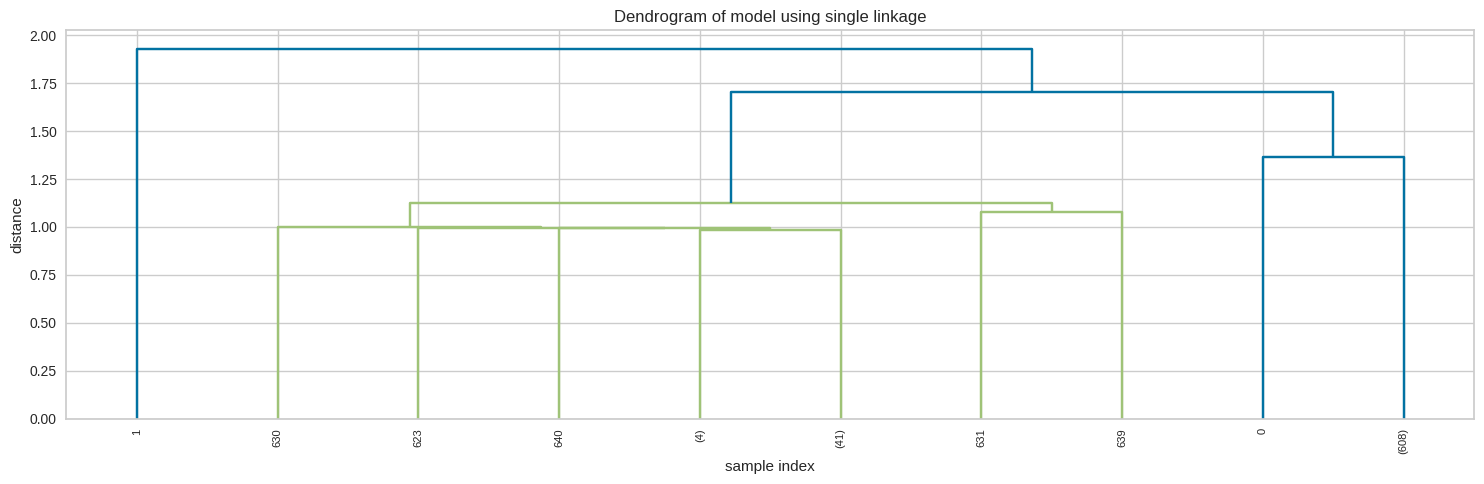

In [ ]:
# We will now visualise these dendograms, limited to the final 10 merges, or 10 clusters for simplicity:

plt.figure (figsize=(15,5))
dendrogram (hier_model_1, truncate_mode="lastp", p=10, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram of model using single linkage")
plt.xlabel ("sample index")
plt.ylabel ("distance")
plt.tight_layout()

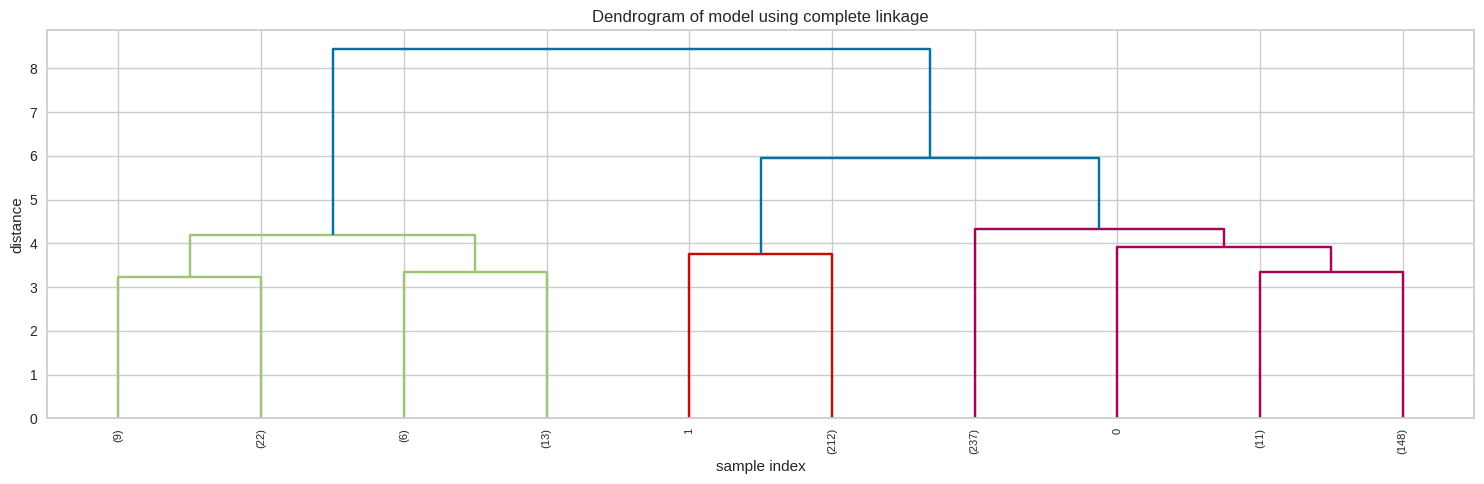

In [ ]:
plt.figure (figsize=(15,5))
dendrogram (hier_model_2, truncate_mode="lastp", p=10, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram of model using complete linkage")
plt.xlabel ("sample index")
plt.ylabel ("distance")
plt.tight_layout()

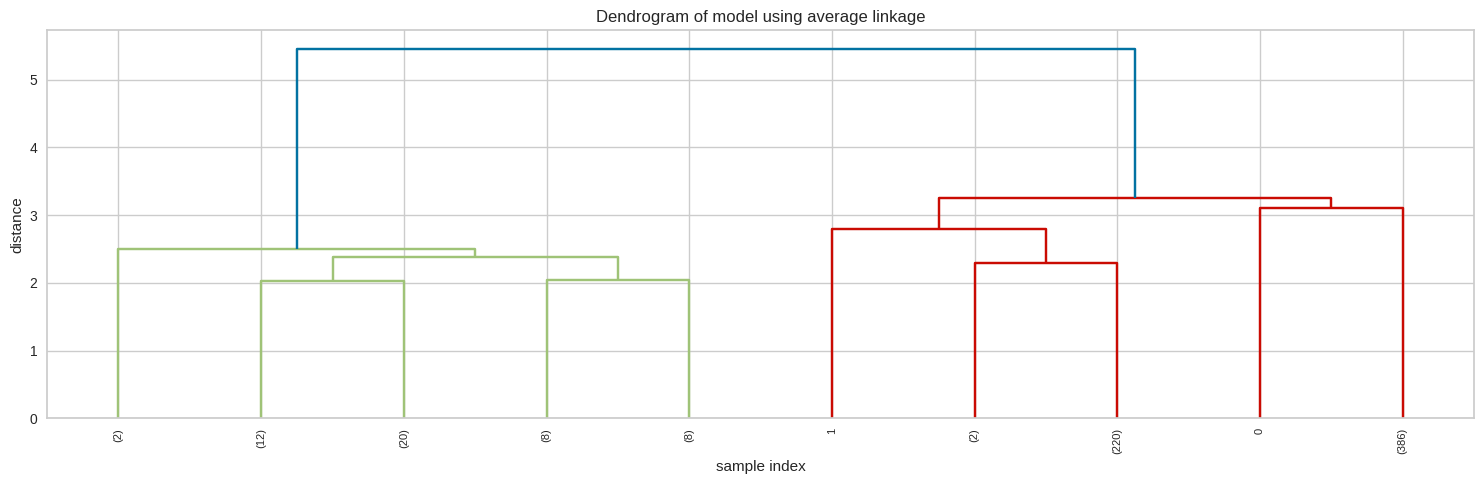

In [ ]:
plt.figure (figsize=(15,5))
dendrogram (hier_model_3, truncate_mode="lastp", p=10, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram of model using average linkage")
plt.xlabel ("sample index")
plt.ylabel ("distance")
plt.tight_layout()

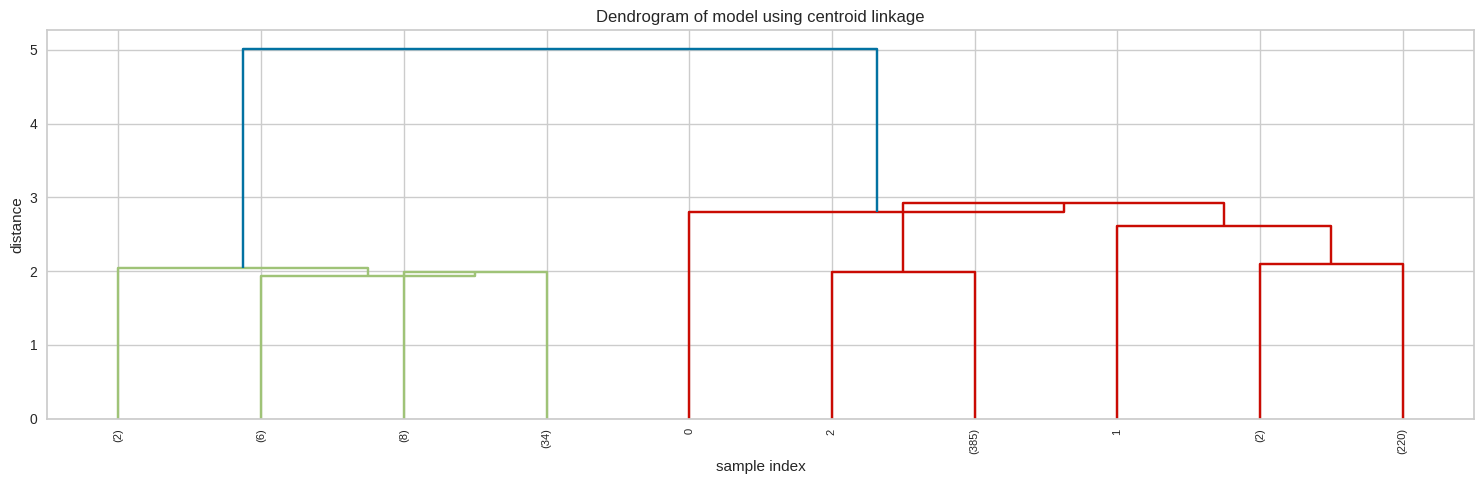

In [ ]:
plt.figure (figsize=(15,5))
dendrogram (hier_model_4, truncate_mode="lastp", p=10, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram of model using centroid linkage")
plt.xlabel ("sample index")
plt.ylabel ("distance")
plt.tight_layout()

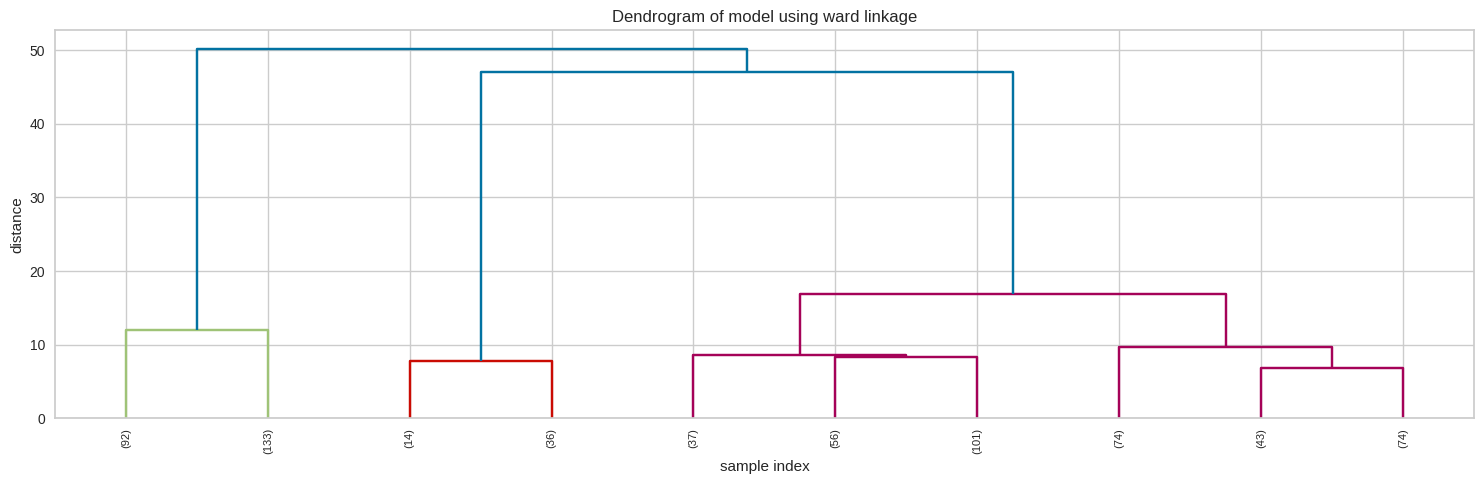

In [ ]:
plt.figure (figsize=(15,5))
dendrogram (hier_model_5, truncate_mode="lastp", p=10, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram of model using ward linkage")
plt.xlabel ("sample index")
plt.ylabel ("distance")
plt.tight_layout()

- We can see that each dedrogram varies slightly depending on the linkage method that was used by the model. In order to find the appropriate number of clusters, we will look at the dedrogram of the model that used the average linkage method, as it has the highest cophenetic correlation score.

- We will find the appropriate number of clusters by drawing an imaginary horizontal cut on the dendrogram right before a large jump occurs in the distance from the bottom. Conceptually, this is similar to finding the appropriate number of clusters through the elbow method for K-Means. This line would find the best balance between accuracy and compression as beneath it, the increase in accuracy is not justified by the increase in complexity, and above it, the increase in compression is not justified by loss of accuracy.

- **When we do this, we find that a model with 3 clusters finds the best balance between accuracy and compression and therefore, we will finalise it as the model we go ahead with.** This is also the same number of clusters we found to be most appropriate using the K-Means clustering approach.

In [ ]:
# We will now proceed to profiling our clusters based on the final model.
# We will start by establishing our final model and adding its predictions to the scaled and orginal datasets:

hier_model_final_bld = AgglomerativeClustering (n_clusters=3, metric= "euclidean", linkage= "average")
hier_model_final_pred = hier_model_final_bld.fit_predict (dataset_an)

dataset_an_org_labels ["Group_Hier"] = hier_model_final_pred
dataset_an_labels ["Group_Hier"] = hier_model_final_pred

dataset_an_org_labels.head()


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans,Group_Hier
0,100000,2,1,1,0,0,0
1,50000,3,0,10,9,1,2
2,50000,7,1,3,4,0,0
3,30000,5,1,1,4,0,0
4,100000,6,0,12,3,2,1


In [ ]:
dataset_an_labels.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans,Group_Hier
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537,0,0
1,0.410293,-0.787585,-1.473731,2.520519,1.891859,1,2
2,0.410293,1.058973,-0.860451,0.134290,0.145528,0,0
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528,0,0
4,1.740187,0.597334,-1.473731,3.202298,-0.203739,2,1


- Great, we can see the predictions have been added to the scaled and orginal datasets, and we can see 3 groups present within them: groups with index labels 0, 1 and 2.

In [ ]:
# We will now do the profiling. We will look at a summary on the orginal dataset so we can see actual values:

dataset_an_org_profile = dataset_an_org_labels.groupby (["Group_Hier"])
dataset_an_org_profile.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans
Group_Hier,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.002584
1,141040.000000,8.740000,0.600000,10.900000,1.080000,2.000000
2,12197.309417,2.403587,0.928251,3.560538,6.883408,1.000000


- We can already see something very interesting. The mean of the Group_KMeans column is almost perfectly 0, 1, and 2 when we group the dataset by the Group_Hier column. This means the clusters created by the K-Means model is almost identical to those created by the Agglomerative Clustering model, just that the labels are mismatched. **This is a great sign that our clustering is in the right direction.**

In [ ]:
print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 0) & (dataset_an_org_labels["Group_Hier"]== 0)].shape[0])
print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 2) & (dataset_an_org_labels["Group_Hier"]== 1)].shape[0])
print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 1) & (dataset_an_org_labels["Group_Hier"]== 2)].shape[0])

1
0
0


- As we can see, there is **all of only one datapoint** from the entire dataset that is categorised differently by the two models.

array([[<Axes: title={'center': 'Avg_Credit_Limit'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Group_KMeans'}, xlabel='[Group_Hier]'>],
       [<Axes: title={'center': 'Total_Credit_Cards'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Total_calls_made'}, xlabel='[Group_Hier]'>],
       [<Axes: title={'center': 'Total_visits_bank'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Total_visits_online'}, xlabel='[Group_Hier]'>]],
      dtype=object)

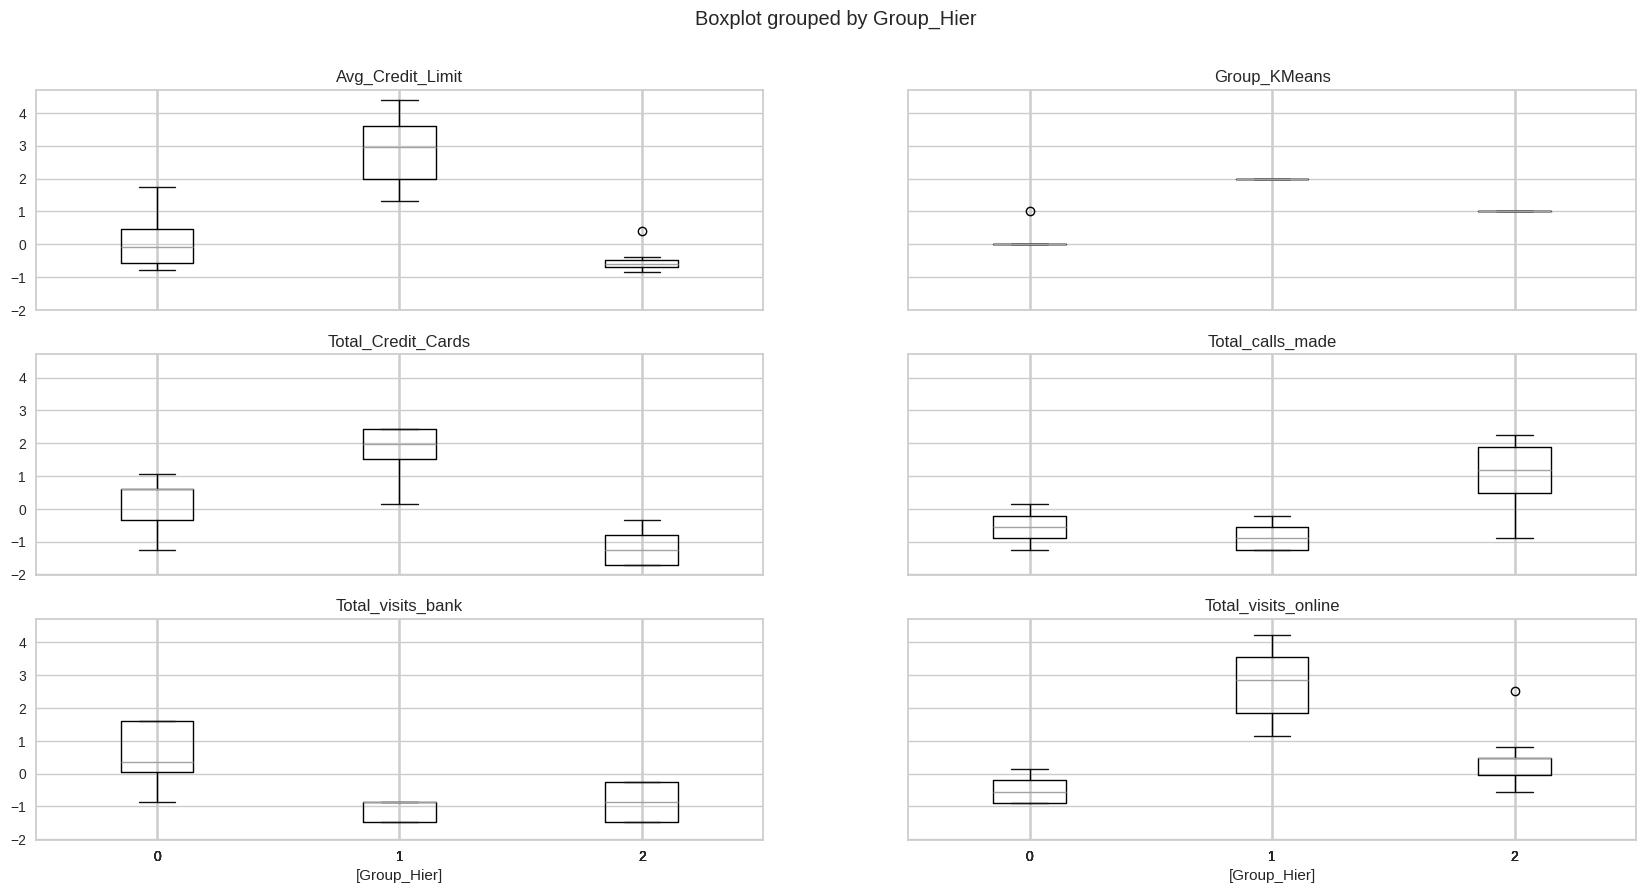

In [ ]:
# We will visualise the grouping using boxplots for each variable.
# We will use the scaled dataset this time to better see patterns and compare:

dataset_an_labels.boxplot (by="Group_Hier", figsize = (20,10))

- Due to the fact that the clustering is almost identical across the two models, we see that the box plots are also the same, just in a different order due to the varying labels.

- We observe all patterns here as well as previously seen with the boxplots of the different clusters made with the K-Means model.

## **K-means vs Hierarchical Clustering**

- As we previously saw, the clustering done by the two models, K-Means Clustering and Hierarchical Clustering, are identical but for a single datapoint.

- This means the cluster profiles and boxplots of the variables broken down by the clusters are also identical, as previously noted as well.

- We will recall these factors and review them side by side for convenience of comparison in this section.

In [ ]:
# Clusters are identical but for a single datapoint that has been categorised differently:

print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 0) & (dataset_an_org_labels["Group_Hier"]== 0)].shape[0])
print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 2) & (dataset_an_org_labels["Group_Hier"]== 1)].shape[0])
print (dataset_an_org_labels [(dataset_an_org_labels["Group_KMeans"]!= 1) & (dataset_an_org_labels["Group_Hier"]== 2)].shape[0])

1
0
0


In [ ]:
# Cluster profiles are identical between the two models, just with different labels:

dataset_an_org_profile = dataset_an_org_labels.groupby (["Group_Hier"])
dataset_an_org_profile.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_KMeans
Group_Hier,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.002584
1,141040.000000,8.740000,0.600000,10.900000,1.080000,2.000000
2,12197.309417,2.403587,0.928251,3.560538,6.883408,1.000000


In [ ]:
dataset_an_org_profile = dataset_an_org_labels.groupby (["Group_KMeans"])
dataset_an_org_profile.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Group_Hier
Group_KMeans,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,0.000000
1,12174.107143,2.410714,0.933036,3.553571,6.870536,1.991071
2,141040.000000,8.740000,0.600000,10.900000,1.080000,1.000000


array([[<Axes: title={'center': 'Avg_Credit_Limit'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Group_KMeans'}, xlabel='[Group_Hier]'>],
       [<Axes: title={'center': 'Total_Credit_Cards'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Total_calls_made'}, xlabel='[Group_Hier]'>],
       [<Axes: title={'center': 'Total_visits_bank'}, xlabel='[Group_Hier]'>,
        <Axes: title={'center': 'Total_visits_online'}, xlabel='[Group_Hier]'>]],
      dtype=object)

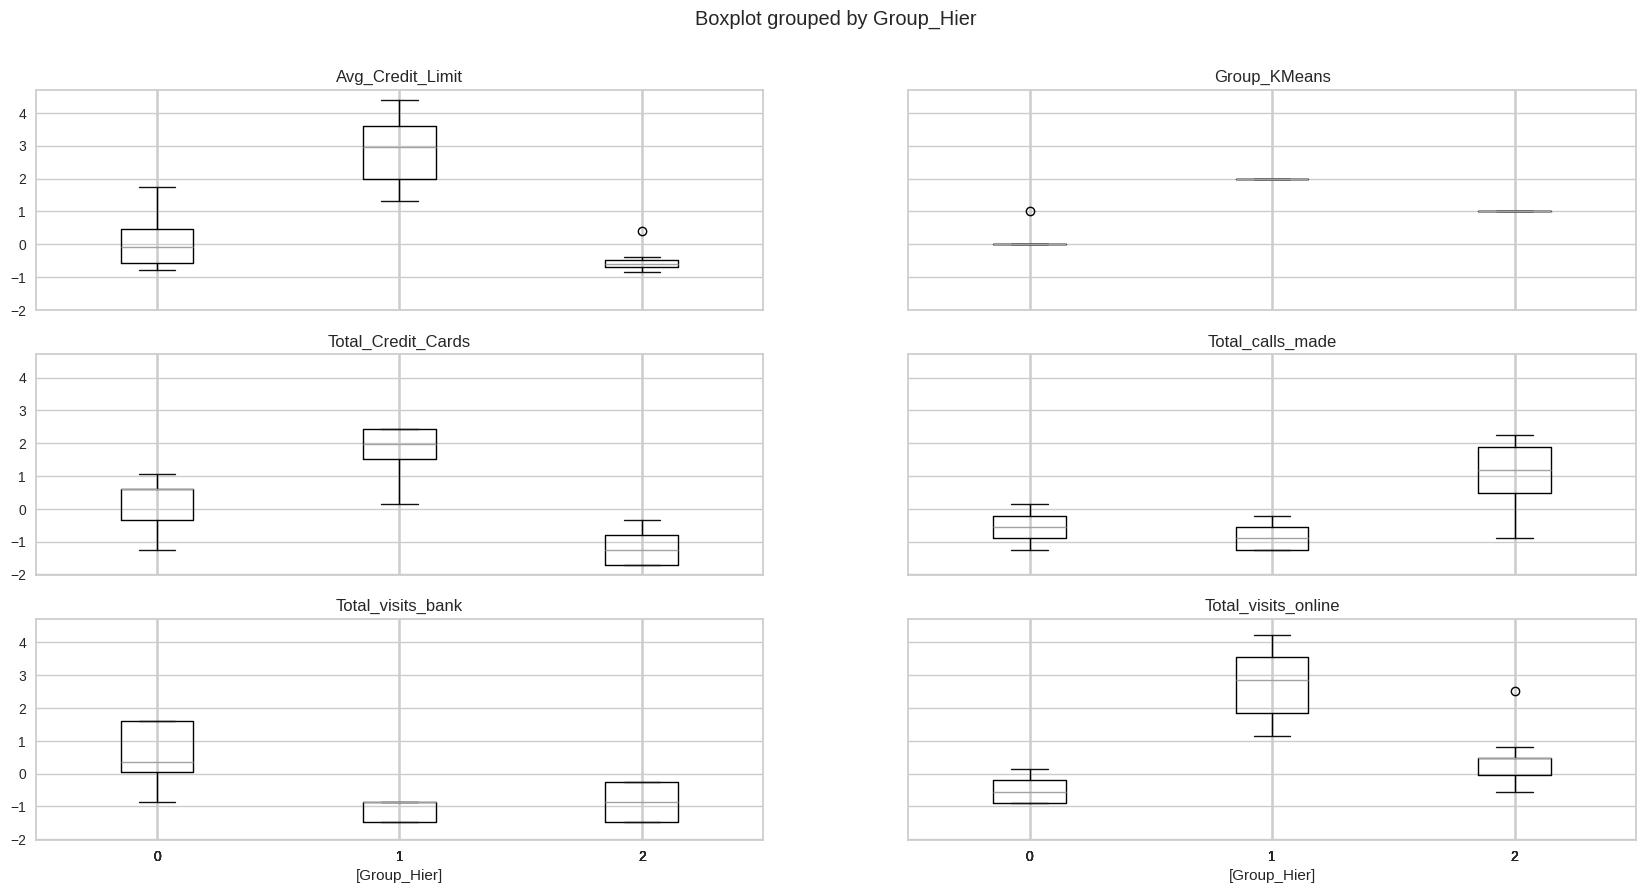

In [ ]:
# Boxplots that visualise the distribution of variables broken down by the clusters are also identical between the two models:

dataset_an_labels.boxplot (by="Group_Hier", figsize = (20,10))

array([[<Axes: title={'center': 'Avg_Credit_Limit'}, xlabel='[Group_KMeans]'>,
        <Axes: title={'center': 'Group_Hier'}, xlabel='[Group_KMeans]'>],
       [<Axes: title={'center': 'Total_Credit_Cards'}, xlabel='[Group_KMeans]'>,
        <Axes: title={'center': 'Total_calls_made'}, xlabel='[Group_KMeans]'>],
       [<Axes: title={'center': 'Total_visits_bank'}, xlabel='[Group_KMeans]'>,
        <Axes: title={'center': 'Total_visits_online'}, xlabel='[Group_KMeans]'>]],
      dtype=object)

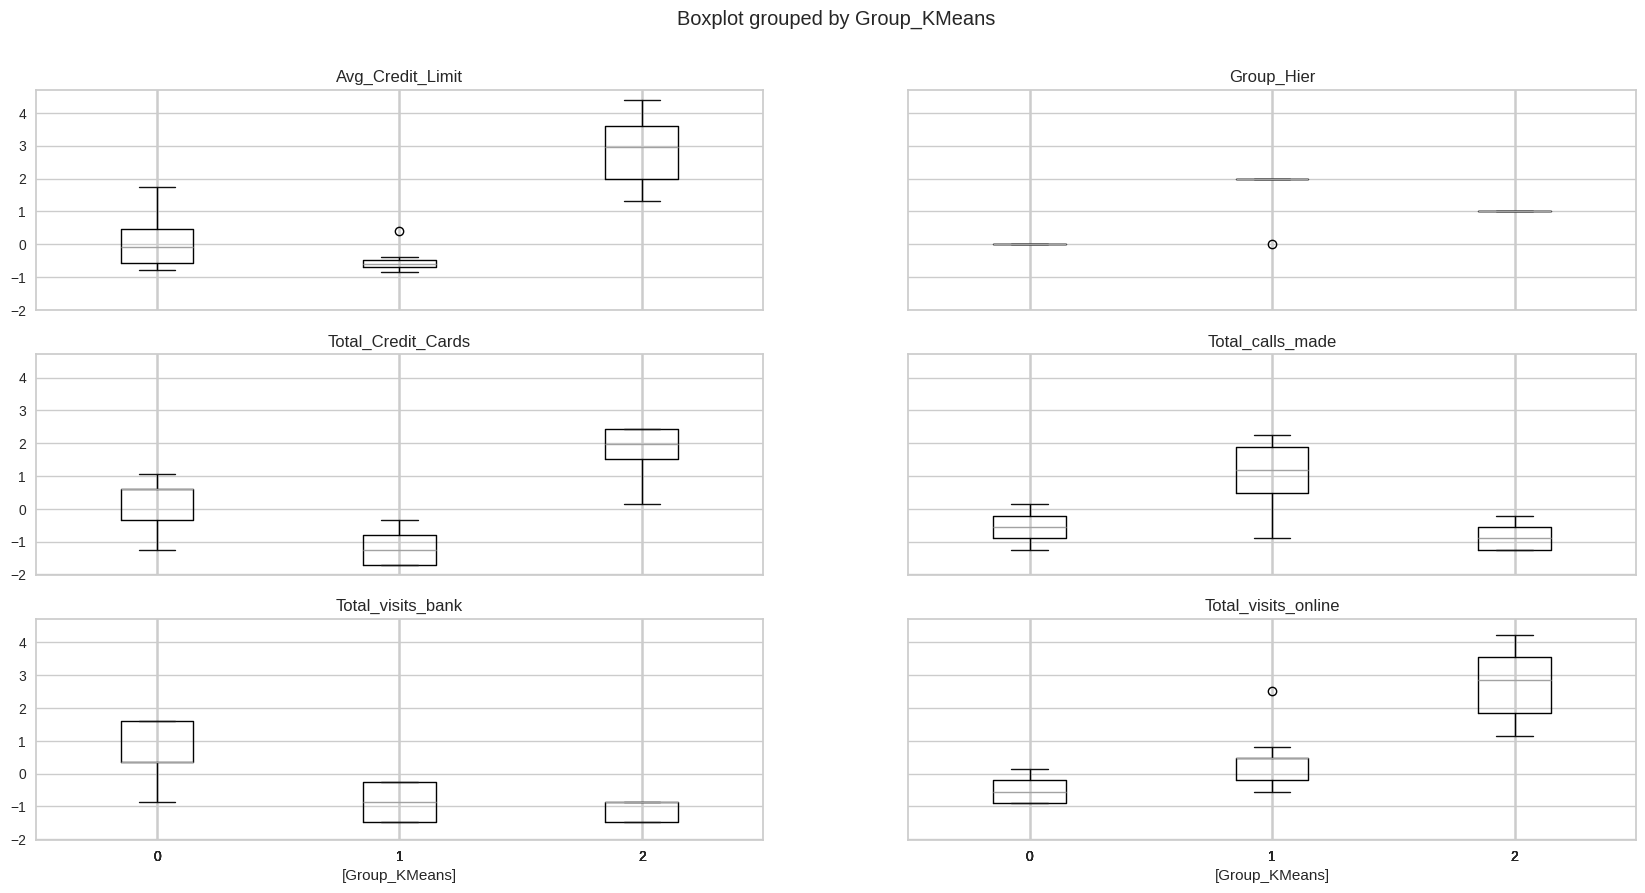

In [ ]:
dataset_an_labels.boxplot (by="Group_KMeans", figsize = (20,10))

- With particular reference to the boxplots of both models over the "Group_Hier" or "Group_KMeans" labels, we see 3 straight lines in the place of what might've been distributions. This is significant as it suggests the clusters made by the two models are identical as we've previously noted as well.

- We can therefore **finalise either of the two models** as they are almost identical and have been picked as they are the best within their respective approaches of K-Means Clustering and Hierarchical Clustering.

- **For the purposes of sticking with one final model, we will choose the one made with K-Means Clustering, model_final_bld.**

## **Actionable Insights & Recommendations**

- **Cluster 0:** This is a cluster that is mostly moderate. It is characterised by average values on the variables of average credit limit (around 31 k) and total number of credit cards held (around 6), beneath average on total calls made (around 2) and total visits online (around 1), and highest on total visits to bank (around 3).

This cluster can be better marketed to by a diverse range of offers as the customers in this cluster are neither too well-off nor lacking, preferably placed to them through physical means such as when they visit the bank. They can be better serviced by in-person support systems that help them with their queries on their visits to the bank.

- **Cluster 1:** Compared to Cluster 0, Cluster 1 has a greater variation across the variables. The customers in this cluster are lowest on the variables of average credit limit (around 12 k) and total number of credit cards held (around 2), highest on total calls made (around 7), beneath average on total visits to the bank (around 1), and above average on total number of visits online (around 4).

This cluster can be better marketed to through a range of offers that are budget friendly, as the customers in this cluster have the lowest financial capacity of all other clusters. These offers might preferably be communicated to them over call or online, as they frequent these mediums. They can be better serviced by providing essential information and trouble-shooting guidance online or verbally when they call the bank.

- **Cluster 2:** Of all three clusters, Cluster 2 is the one with the greatest swing across variables. The customers in this cluster are highest on the variables of average credit limit (around 145.5 k), total number of credit cards held (around 9) and total number of visits online (around 11), and lowest on total calls made (around 1) and total visits made to the bank (around 1).

This cluster can be better marketed to with offers that are towards the higher end and more attractive or extravagant, as of all clusters, the customers in this cluster are the most financially capable ones. These offers can be placed online as that is the medium most frequented by the customers in this cluster. They can be better serviced by offering problem resolution avenues online, where they can find them and self-service or contact the bank for further assistance.